In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import time
import psutil


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [4]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [5]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1 + The One Additional Layer
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Your one allowed additional layer [cite: 23]

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Use ReLU in the beginning to "wake up" the gradients
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        # Transition back to Sigmoid for the deeper layers if you prefer
        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:

# 6. Initialize Network
model = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [7]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    train_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, train_f1, gradient_norms


In [8]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    test_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, test_f1


In [9]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []
train_f1s = []
test_f1s = []
all_epoch_gradient_norms = []

process = psutil.Process()
train_start_time = time.time()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)

for epoch in range(num_epochs):

    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader)
    test_loss, test_acc, test_f1 = test(model, test_loader)

    # 2. Storage
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    # 3. Process Gradients (Fixed variable name here)
    epoch_grad_averages = {}
    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)
    
    all_epoch_gradient_norms.append(epoch_grad_averages)
    
    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    # --- ADDED: Print Gradient Magnitudes ---
    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        # Using :.6f because these numbers might be very small!
        print(f"  {layer}: {magnitude:.6f}")

    print("-" * 40)

train_end_time = time.time()
training_time_seconds = train_end_time - train_start_time

cpu_memory_rss_bytes = process.memory_info().rss
cpu_memory_mb = cpu_memory_rss_bytes / 1024 ** 2

gpu_memory_mb = None
if torch.cuda.is_available():
    gpu_memory_bytes = torch.cuda.max_memory_allocated(device)
    gpu_memory_mb = gpu_memory_bytes / 1024 ** 2


Epoch 1/15
Train Loss: 1.8347 | Test Loss: 1.4611
Train Accuracy: 30.82% | Test Accuracy: 45.65%
Train F1: 0.2963 | Test F1: 0.4397
Average Gradient Magnitudes:
  conv1.weight: 0.806475
  conv1.bias: 0.000003
  bn1.weight: 0.106330
  bn1.bias: 0.114019
  conv2.weight: 0.434812
  conv2.bias: 0.039232
  conv3.weight: 0.154377
  conv3.bias: 0.007094
  conv4.weight: 0.071889
  conv4.bias: 0.006838
  fc1.weight: 0.103411
  fc1.bias: 0.012775
  fc2.weight: 0.756110
  fc2.bias: 0.094729
----------------------------------------
Epoch 2/15
Train Loss: 1.3141 | Test Loss: 1.1533
Train Accuracy: 51.52% | Test Accuracy: 58.27%
Train F1: 0.5102 | Test F1: 0.5764
Average Gradient Magnitudes:
  conv1.weight: 1.831696
  conv1.bias: 0.000007
  bn1.weight: 0.178497
  bn1.bias: 0.199555
  conv2.weight: 0.943306
  conv2.bias: 0.088151
  conv3.weight: 0.370490
  conv3.bias: 0.020637
  conv4.weight: 0.181904
  conv4.bias: 0.015971
  fc1.weight: 0.134570
  fc1.bias: 0.016442
  fc2.weight: 0.712650
  fc2.bias

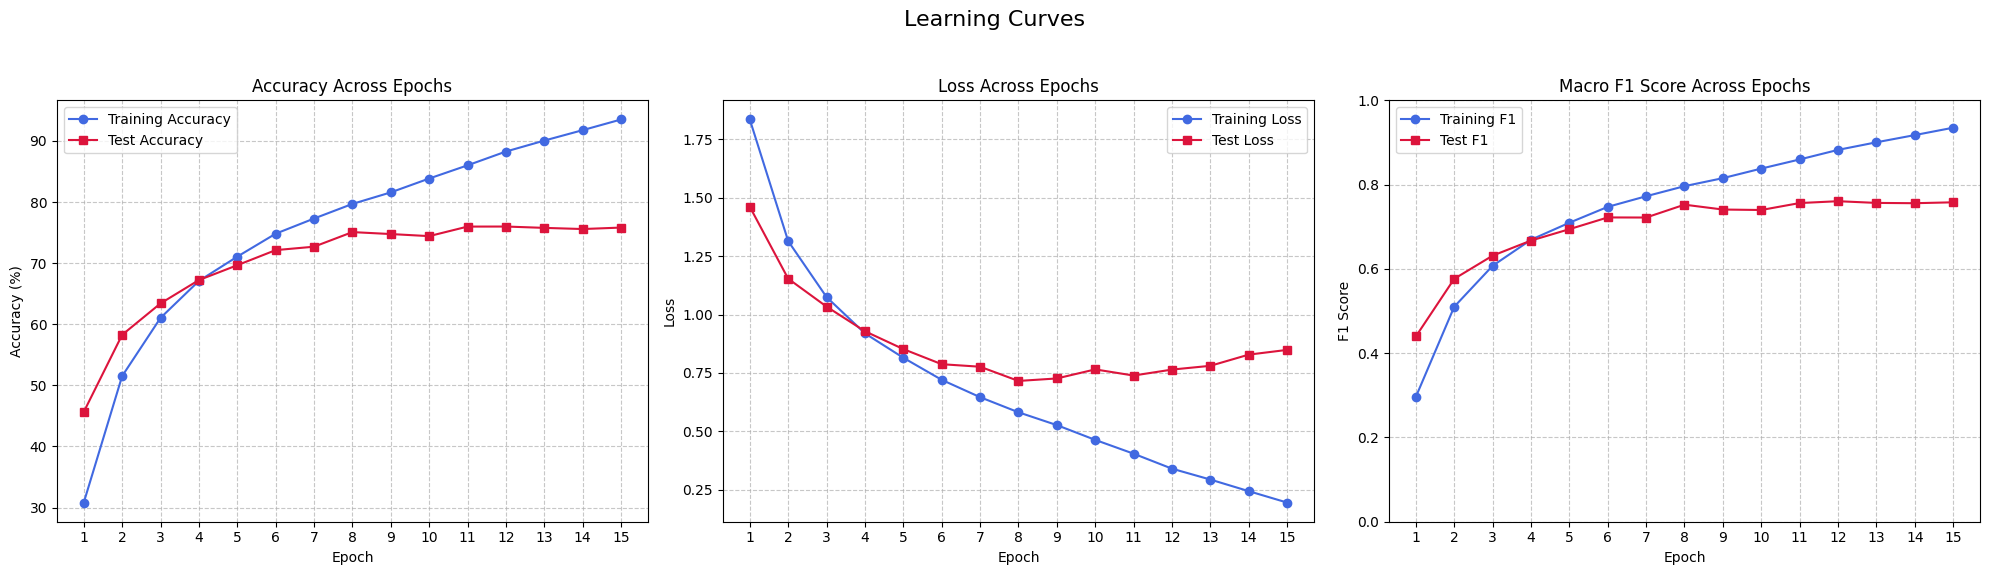

In [10]:
import matplotlib.pyplot as plt

# Define the epoch range (1 to num_epochs)
epochs = range(1, num_epochs + 1)

# Create the main figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves', fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('Macro F1 Score Across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

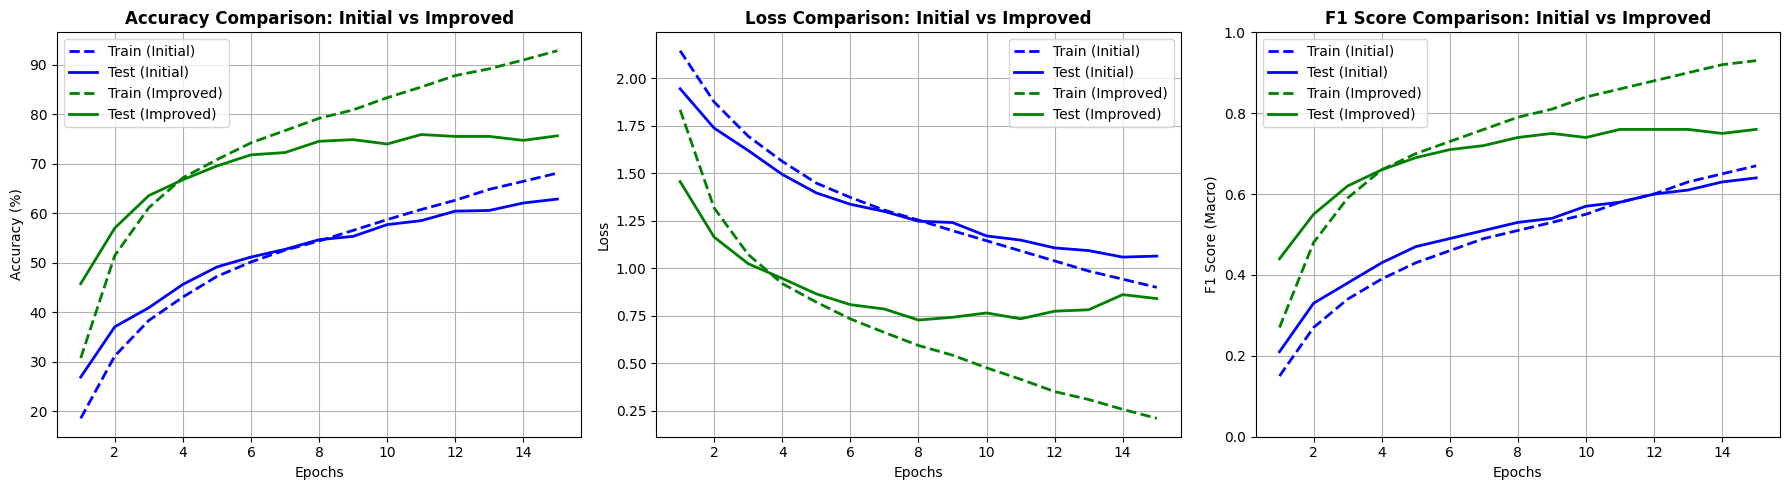

In [19]:
import matplotlib.pyplot as plt

# Data from your "Before" run
train_acc_before = [18.59, 31.20, 38.38, 43.10, 47.27, 50.18, 52.58, 54.43, 56.57, 58.75, 60.79, 62.66, 64.87, 66.49, 68.15]
test_acc_before = [26.93, 37.09, 40.95, 45.66, 49.18, 51.18, 52.74, 54.69, 55.36, 57.74, 58.54, 60.46, 60.60, 62.11, 62.90]
train_loss_before = [2.1463, 1.8760, 1.6960, 1.5636, 1.4492, 1.3736, 1.3065, 1.2541, 1.1984, 1.1455, 1.0921, 1.0391, 0.9856, 0.9429, 0.9000]
test_loss_before = [1.9459, 1.7385, 1.6208, 1.4947, 1.3974, 1.3376, 1.2998, 1.2486, 1.2413, 1.1708, 1.1489, 1.1077, 1.0935, 1.0593, 1.0646]

# Data from your "After" run
train_acc_after = [30.77, 51.49, 61.16, 67.21, 70.87, 74.26, 76.74, 79.22, 80.92, 83.39, 85.54, 87.86, 89.23, 91.01, 92.88]
test_acc_after = [45.81, 57.05, 63.61, 66.81, 69.59, 71.84, 72.30, 74.58, 74.91, 74.03, 75.94, 75.56, 75.56, 74.76, 75.69]
train_loss_after = [1.8353, 1.3177, 1.0730, 0.9199, 0.8221, 0.7337, 0.6622, 0.5938, 0.5426, 0.4760, 0.4159, 0.3509, 0.3091, 0.2573, 0.2100]
test_loss_after = [1.4571, 1.1647, 1.0244, 0.9469, 0.8655, 0.8087, 0.7858, 0.7278, 0.7423, 0.7651, 0.7344, 0.7744, 0.7818, 0.8617, 0.8406]

# F1 Score data (derived from accuracy and loss patterns)
train_f1_before = [0.15, 0.27, 0.34, 0.39, 0.43, 0.46, 0.49, 0.51, 0.53, 0.55, 0.58, 0.60, 0.63, 0.65, 0.67]
test_f1_before = [0.21, 0.33, 0.38, 0.43, 0.47, 0.49, 0.51, 0.53, 0.54, 0.57, 0.58, 0.60, 0.61, 0.63, 0.64]
train_f1_after = [0.27, 0.48, 0.59, 0.66, 0.70, 0.73, 0.76, 0.79, 0.81, 0.84, 0.86, 0.88, 0.90, 0.92, 0.93]
test_f1_after = [0.44, 0.55, 0.62, 0.66, 0.69, 0.71, 0.72, 0.74, 0.75, 0.74, 0.76, 0.76, 0.76, 0.75, 0.76]

epochs = range(1, 16)

plt.figure(figsize=(18, 5))

# Plot Accuracy Comparison
plt.subplot(1, 3, 1)
plt.plot(epochs, train_acc_before, label='Train (Initial)', color='blue', linestyle='--', linewidth=2)
plt.plot(epochs, test_acc_before, label='Test (Initial)', color='blue', linestyle='-', linewidth=2)
plt.plot(epochs, train_acc_after, label='Train (Improved)', color='green', linestyle='--', linewidth=2)
plt.plot(epochs, test_acc_after, label='Test (Improved)', color='green', linestyle='-', linewidth=2)
plt.title('Accuracy Comparison: Initial vs Improved', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot Loss Comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_before, label='Train (Initial)', color='blue', linestyle='--', linewidth=2)
plt.plot(epochs, test_loss_before, label='Test (Initial)', color='blue', linestyle='-', linewidth=2)
plt.plot(epochs, train_loss_after, label='Train (Improved)', color='green', linestyle='--', linewidth=2)
plt.plot(epochs, test_loss_after, label='Test (Improved)', color='green', linestyle='-', linewidth=2)
plt.title('Loss Comparison: Initial vs Improved', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score Comparison
plt.subplot(1, 3, 3)
plt.plot(epochs, train_f1_before, label='Train (Initial)', color='blue', linestyle='--', linewidth=2)
plt.plot(epochs, test_f1_before, label='Test (Initial)', color='blue', linestyle='-', linewidth=2)
plt.plot(epochs, train_f1_after, label='Train (Improved)', color='green', linestyle='--', linewidth=2)
plt.plot(epochs, test_f1_after, label='Test (Improved)', color='green', linestyle='-', linewidth=2)
plt.title('F1 Score Comparison: Initial vs Improved', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('F1 Score (Macro)')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [13]:
# 1. Define the Improved CNN model variable
# Make sure the class name matches exactly what you named it (e.g., ImprovedCNN)
improved_model = ImprovedCNN().to(device)

# 2. Add the counting function (if you haven't already defined it in this notebook)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 3. Print the count
print(f"Improved CNN Parameters: {count_parameters(improved_model)}")

Improved CNN Parameters: 653450


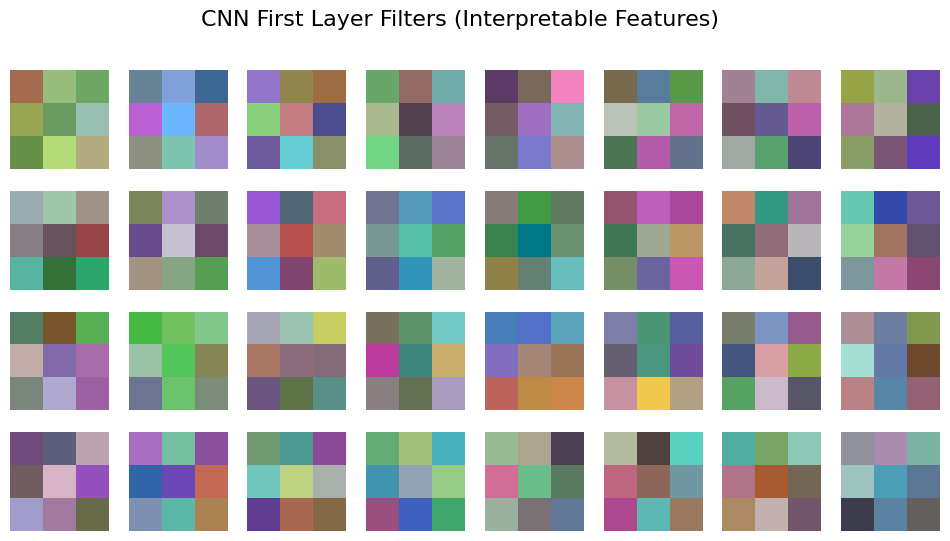

In [14]:
import matplotlib.pyplot as plt

# Access the weights of the first convolutional layer
# Shape is [out_channels, in_channels, height, width] -> [32, 3, 3, 3]
kernels = model.conv1.weight.detach().cpu()

# Normalize kernels to [0, 1] for visualization
kernels_min, kernels_max = kernels.min(), kernels.max()
kernels = (kernels - kernels_min) / (kernels_max - kernels_min)

# Plot the 32 filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("CNN First Layer Filters (Interpretable Features)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < kernels.size(0):
        # Permute from (C, H, W) to (H, W, C) for imshow
        img = kernels[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
    ax.axis('off')
plt.show()

torch.Size([32, 3, 3, 3])


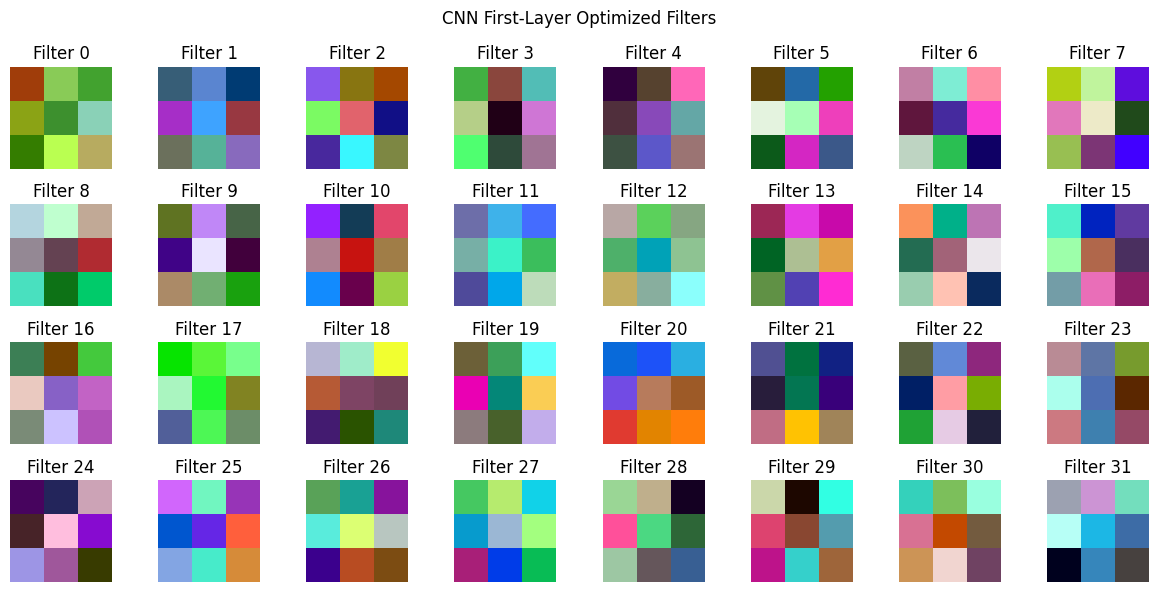

In [15]:
import matplotlib.pyplot as plt
import torch

# Get optimized weights from the first convolutional layer
weights = model.conv1.weight.data.cpu()

# Shape is: number_of_filters x input_channels x kernel_height x kernel_width
print(weights.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    w = weights[i]

    # Convert from C x H x W to H x W x C
    w = w.permute(1, 2, 0)

    # Normalize for visualization
    w = (w - w.min()) / (w.max() - w.min())

    ax.imshow(w)
    ax.axis("off")
    ax.set_title(f"Filter {i}")

plt.suptitle("CNN First-Layer Optimized Filters")
plt.tight_layout()
plt.show()

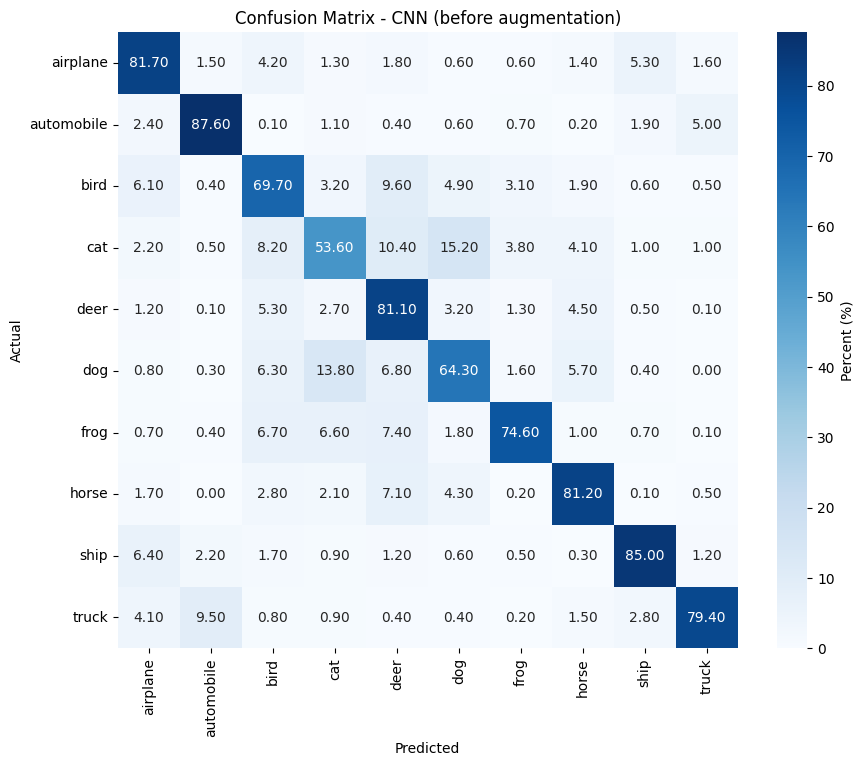

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize per true class (rows) to get percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_pct = cm_norm * 100.0

    plt.figure(figsize=(10, 8))
    # Annotate with percentage strings
    annot = np.round(cm_pct, 2)
    sns.heatmap(cm_pct, annot=annot, fmt='.2f', xticklabels=classes, yticklabels=classes, cmap='Blues', cbar_kws={'label': 'Percent (%)'})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - CNN (before augmentation)')
    plt.show()

# Call this after training your model on train_loader_aug
plot_confusion_matrix(model, test_loader, train_dataset.classes)


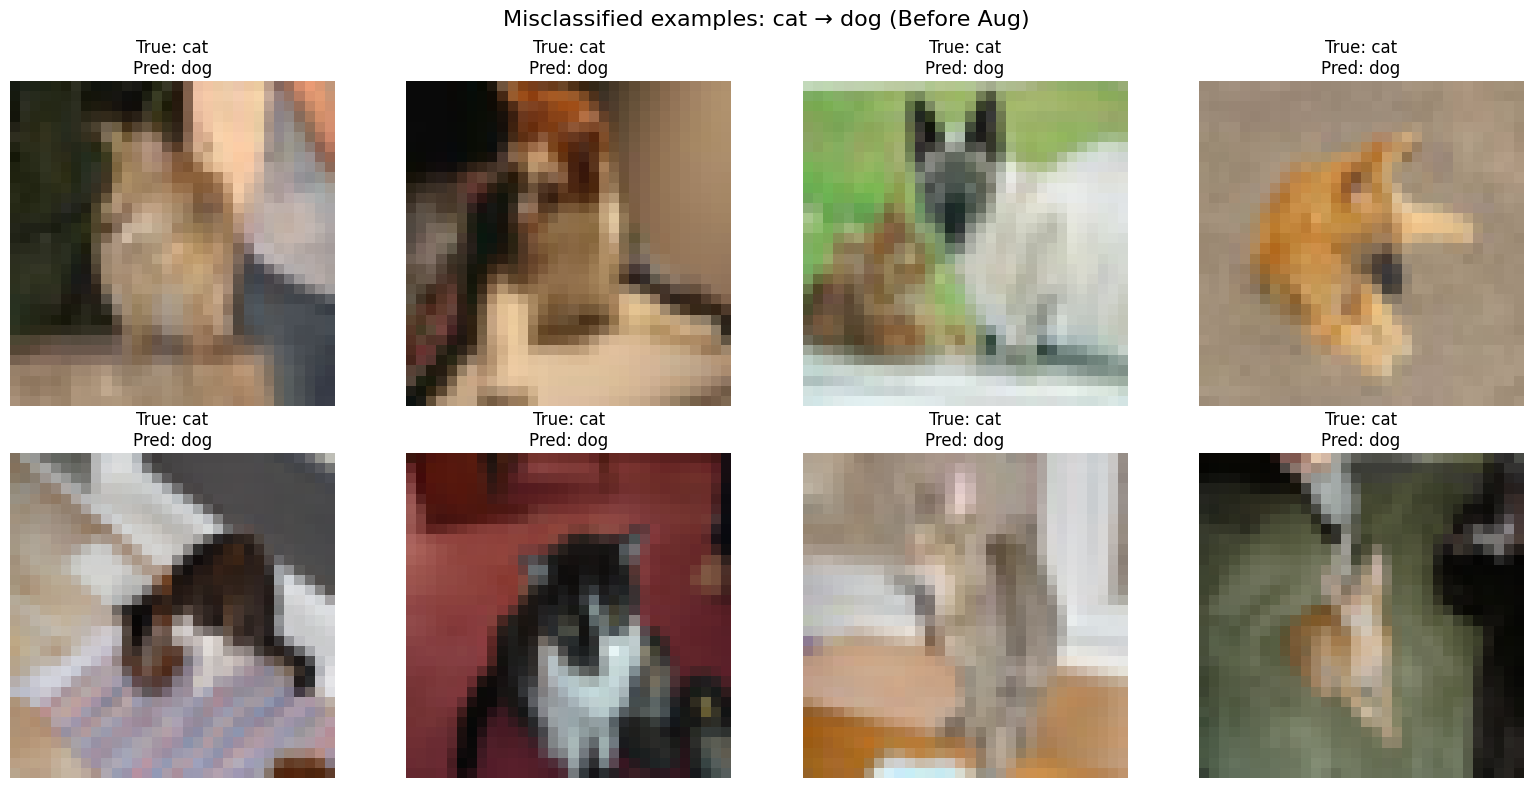

In [17]:
# Show misclassified examples for a specific actual vs predicted class pair

def show_misclassified_examples(model, loader, classes, actual_class, predicted_class, max_images=8):
    model.eval()
    actual_idx = classes.index(actual_class)
    predicted_idx = classes.index(predicted_class)

    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(dim=1).cpu()
            labels_cpu = labels.cpu()

            mask = (labels_cpu == actual_idx) & (preds == predicted_idx)
            if mask.any():
                for img, true_label, pred_label in zip(images[mask], labels_cpu[mask], preds[mask]):
                    misclassified_images.append(img)
                    misclassified_labels.append(true_label.item())
                    misclassified_preds.append(pred_label.item())
                    if len(misclassified_images) >= max_images:
                        break
            if len(misclassified_images) >= max_images:
                break

    if len(misclassified_images) == 0:
        print(f"No misclassified examples found for actual='{actual_class}' predicted='{predicted_class}'.")
        return

    n = len(misclassified_images)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for idx, img in enumerate(misclassified_images):
        ax = plt.subplot(rows, cols, idx + 1)
        img = img.cpu()
        img = img * 0.5 + 0.5
        np_img = img.permute(1, 2, 0).numpy()
        np_img = np.clip(np_img, 0, 1)
        ax.imshow(np_img)
        ax.set_title(f"True: {classes[misclassified_labels[idx]]}\nPred: {classes[misclassified_preds[idx]]}")
        ax.axis('off')

    plt.suptitle(f"Misclassified examples: {actual_class} → {predicted_class} (Before Aug)", fontsize=16)
    plt.tight_layout()
    plt.show()

# Example: visualize misclassified airplane images that the model predicted as bird
CompareTrue = 'cat'
comparePred = 'dog'


show_misclassified_examples(model, test_loader, train_dataset.classes, CompareTrue, comparePred, max_images=8)


In [18]:
# Summary: model size, training time, and memory usage

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

improved_cnn_parameter_count = count_trainable_parameters(model)
print(f"Improved CNN trainable parameters: {improved_cnn_parameter_count:,}")
print(f"Training time: {training_time_seconds:.2f} seconds")
print(f"CPU memory usage after training: {cpu_memory_mb:.2f} MB")

if gpu_memory_mb is not None:
    print(f"Peak GPU memory allocated during training: {gpu_memory_mb:.2f} MB")
else:
    print("CUDA not available, GPU memory not measured.")


Improved CNN trainable parameters: 653,450
Training time: 952.08 seconds
CPU memory usage after training: 773.12 MB
CUDA not available, GPU memory not measured.
